# 18 · Training  (`18_nonvlm_tr`)

`GradeXGBoostTrainer` — trains a **3-tier PSA grading classifier** on any feature DataFrame.

| Tier | PSA grades | Meaning |
|---|---|---|
| 0 · Don't grade | ≤6 | Card value < grading fee |
| 1 · Consider | 7–8 | Depends on card scarcity |
| 2 · Grade it | 9–10 | Slab premium justifies the fee |

**Workflow:**
1. Load `haiku_features.csv` or `cv_features.csv`
2. Create a `GradeXGBoostTrainer` and call `.fit(df)`
3. Inspect CV metrics and plots
4. Call `.save("models/haiku_xgb.pkl")` — saves the model + feature list
5. Load in `18_nonvlm_te.ipynb` for single-image inference

In [1]:
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("inline" if "ipykernel" in sys.modules else "Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (log_loss, accuracy_score, classification_report,
                              confusion_matrix)
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
sys.path.insert(0, "."); sys.path.insert(0, "../backend")
import nonvlm_cv as N
sns.set_theme(style="whitegrid", context="notebook")

BASE   = Path("feature_extraction_dataset")
MODELS = Path("models"); MODELS.mkdir(exist_ok=True)
OUT    = Path("diag");   OUT.mkdir(exist_ok=True)
SEED   = 7
print("Ready")

Ready


## GradeXGBoostTrainer

In [2]:
class GradeXGBoostTrainer:
    """Train a 3-tier XGBoost grade classifier from a feature DataFrame.

    Usage:
        df    = pd.read_csv("feature_extraction_dataset/haiku_features.csv")
        trainer = GradeXGBoostTrainer(source="haiku")
        trainer.fit(df)
        trainer.print_metrics()
        trainer.plot_confusion()
        trainer.save("models/haiku_xgb.pkl")
    """

    TIER_MAP    = {5:0, 6:0, 7:1, 8:1, 9:2, 10:3}
    TIER_LABELS = ["Don't grade  (≤6)", "Consider  (7–8)", "PSA 9  (Near Mint)", "PSA 10  (Gem Mint)"]
    TIER_SHORT  = ["≤6", "7–8", "PSA 9", "PSA 10"]
    TIER_COLORS = ["#e45756", "#f28e2b", "#4c78a8", "#54a24b"]
    N_TIERS     = 4
    CEN_COLS    = ["cen.lr_deviation", "cen.tb_deviation"]

    # XGBoost hyperparameters (tuned for this dataset size)
    XGB_PARAMS  = dict(objective="multi:softprob", num_class=4,
                       n_estimators=500, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                       eval_metric="mlogloss", verbosity=0)

    def __init__(self, source: str = "haiku", n_top_features: int = 15, seed: int = SEED):
        """
        Args:
            source:           "haiku" or "cv" — controls which feature columns to look for
            n_top_features:   keep top-N features selected by mutual information
            seed:             random seed for reproducibility
        """
        assert source in ("haiku", "cv"), "source must be 'haiku' or 'cv'"
        self.source          = source
        self.n_top_features  = n_top_features
        self.seed            = seed
        # set after fit
        self.feature_cols_   = None   # list of selected feature columns
        self.model_          = None   # XGBoost fitted on full data
        self.oof_proba_      = None   # out-of-fold probabilities (n_cards × 3)
        self.cv_metrics_     = None   # dict of cross-val metrics
        self.n_folds_        = None

    # ── helpers ─────────────────────────────────────────────────────────────

    def _feature_cols(self, df: pd.DataFrame) -> list:
        """Infer feature columns from df based on source."""
        if self.source == "cv":
            candidates = [c for c in df.columns if c.startswith("cv.")]
        else:
            candidates = [c for c in N.FEATURE_COLUMNS if c in df.columns]
        return candidates

    def _select_features(self, df: pd.DataFrame, y: np.ndarray) -> list:
        """Select top-N features by mutual information."""
        feat_cols = self._feature_cols(df)
        X = df[feat_cols + self.CEN_COLS].apply(pd.to_numeric, errors="coerce").fillna(0)
        mi = mutual_info_classif(X.values, y, random_state=self.seed)
        scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
        top = scores.head(self.n_top_features).index.tolist()
        # always include centering (strongest predictors)
        for c in self.CEN_COLS:
            if c not in top:
                top.append(c)
        return top

    def _build_X(self, df: pd.DataFrame, feature_cols: list) -> np.ndarray:
        return df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values

    def _prep_df(self, df: pd.DataFrame):
        """Filter error rows and build y."""
        clean = df[df.get("error", pd.Series("")).isna() |
                   (df.get("error", pd.Series("")).astype(str).str.strip() == "")]
        y = np.array([self.TIER_MAP[g] for g in clean["actual_psa"].astype(int)])
        return clean.reset_index(drop=True), y

    # ── public API ───────────────────────────────────────────────────────────

    def fit(self, df: pd.DataFrame, n_folds: int = 5) -> "GradeXGBoostTrainer":
        """Select features, cross-validate, and fit a final model on all data.

        Args:
            df:      feature DataFrame (haiku or cv)
            n_folds: stratified K-fold splits for evaluation
        Returns:
            self (for chaining)
        """
        self._last_df_ = df
        clean, y = self._prep_df(df)
        min_cls  = int(pd.Series(y).value_counts().min())
        n_folds  = min(n_folds, min_cls)
        self.n_folds_ = n_folds

        print(f"[{self.source.upper()}] {len(clean)} cards  ({n_folds}-fold CV)")
        for t, lbl in enumerate(self.TIER_LABELS):
            n = (y == t).sum()
            print(f"  {lbl:28}  {n:4d}  ({100*n/len(y):.0f}%)")

        # feature selection
        self.feature_cols_ = self._select_features(clean, y)
        print(f"\n  Selected {len(self.feature_cols_)} features "
              f"(top-{self.n_top_features} MI + centering)")

        X = self._build_X(clean, self.feature_cols_)

        # cross-validate
        skf  = StratifiedKFold(n_folds, shuffle=True, random_state=self.seed)
        clf  = xgb.XGBClassifier(**self.XGB_PARAMS, random_state=self.seed)
        oof  = cross_val_predict(clf, X, y, cv=skf, method="predict_proba")
        self.oof_proba_  = oof
        mode = oof.argmax(axis=1)

        per_tier = {}
        for t in range(self.N_TIERS):
            mask = y == t
            per_tier[self.TIER_SHORT[t]] = round(100*accuracy_score(y[mask],mode[mask]),1)

        self.cv_metrics_ = {
            "source":       self.source,
            "n_cards":      len(clean),
            "n_features":   len(self.feature_cols_),
            "n_folds":      n_folds,
            "log_loss":     round(log_loss(y, oof), 3),
            "exact%":       round(100*accuracy_score(y, mode), 1),
            "within1%":     round(100*np.mean(np.abs(mode - y) <= 1), 1),
            **{f"acc_{k}%": v for k, v in per_tier.items()},
        }

        # final model on full data
        self.model_ = xgb.XGBClassifier(**self.XGB_PARAMS, random_state=self.seed)
        self.model_.fit(X, y)
        print(f"\n  CV results:  log-loss={self.cv_metrics_['log_loss']:.3f}  "
              f"exact={self.cv_metrics_['exact%']:.1f}%  "
              f"within-1={self.cv_metrics_['within1%']:.1f}%")
        return self

    def print_metrics(self) -> None:
        """Print a formatted metrics table."""
        m = self.cv_metrics_
        if m is None:
            print("Not fitted yet. Call .fit(df) first."); return
        print(f"\n{'═'*50}")
        print(f"  {self.source.upper()} model — {m['n_folds']}-fold CV metrics")
        print(f"{'─'*50}")
        print(f"  Cards:           {m['n_cards']}")
        print(f"  Features:        {m['n_features']}")
        print(f"  Log-loss:        {m['log_loss']:.3f}")
        print(f"  Exact tier %:    {m['exact%']:.1f}%")
        print(f"  Within-1 tier %: {m['within1%']:.1f}%")
        print(f"  Per-tier accuracy:")
        for short in self.TIER_SHORT:
            print(f"    {short:6}  {m.get(f'acc_{short}%','—')}%")

    def plot_proba(self, save_path: str = None) -> None:
        """Plot aggregated OOF probability distributions per tier."""
        if self.oof_proba_ is None:
            print("Not fitted."); return
        df_fit, y = self._prep_df(self._last_df_)  # noqa — set in fit_and_store
        proba = self.oof_proba_
        fig, axes = plt.subplots(1, self.N_TIERS, figsize=(5*self.N_TIERS, 5), sharey=True)
        for t, ax in enumerate(axes):
            mask  = y == t
            P     = proba[mask]
            mean_p = P.mean(0); se = P.std(0) / np.sqrt(max(mask.sum(),1))
            bar_c = [self.TIER_COLORS[j] if j==t else "#aec7e8" for j in range(self.N_TIERS)]
            ax.bar(range(self.N_TIERS), mean_p, color=bar_c, edgecolor="white", alpha=0.9)
            ax.errorbar(range(self.N_TIERS), mean_p, yerr=se,
                        fmt="none", color="black", capsize=4)
            ax.set_xticks(range(self.N_TIERS))
            ax.set_xticklabels(self.TIER_SHORT, fontsize=11)
            ax.set_title(f"True: {self.TIER_LABELS[t]}\n(n={mask.sum()})", fontsize=10)
            ax.set_ylim(0, 1.05)
            for j, (mp, se_j) in enumerate(zip(mean_p, se)):
                ax.text(j, mp+se_j+0.02, f"{mp:.2f}", ha="center",
                        fontsize=10, fontweight="bold")
        axes[0].set_ylabel("Mean P(tier) ± SE")
        m = self.cv_metrics_
        plt.suptitle(f"{self.source.upper()} model — OOF probability distributions\n"
                     f"exact={m['exact%']:.1f}%   log-loss={m['log_loss']:.3f}")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=110)
        plt.show()

    def plot_confusion(self, save_path: str = None) -> None:
        """Plot 3×3 mean probability confusion matrix."""
        if self.oof_proba_ is None:
            print("Not fitted."); return
        _, y = self._prep_df(self._last_df_)
        conf = np.zeros((self.N_TIERS, self.N_TIERS))
        for t in range(self.N_TIERS):
            mask = y==t
            if mask.sum(): conf[t] = self.oof_proba_[mask].mean(0)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(conf, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=self.TIER_SHORT, yticklabels=self.TIER_SHORT,
                    ax=ax, annot_kws={"size":13}, vmin=0, vmax=1)
        ax.set_xlabel("Predicted tier"); ax.set_ylabel("True tier")
        m = self.cv_metrics_
        ax.set_title(f"{self.source.upper()} model — confusion matrix\n"
                     f"exact={m['exact%']:.1f}%   log-loss={m['log_loss']:.3f}")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=110)
        plt.show()

    def plot_feature_importance(self, top_n: int = 15, save_path: str = None) -> None:
        """Plot XGBoost feature importance."""
        if self.model_ is None:
            print("Not fitted."); return
        fi = pd.Series(self.model_.feature_importances_,
                       index=self.feature_cols_, name="gain"
                       ).sort_values(ascending=False).head(top_n)
        fig, ax = plt.subplots(figsize=(8, 6))
        fi.plot.barh(ax=ax, color="#4c78a8"); ax.invert_yaxis()
        ax.set_title(f"{self.source.upper()} — top-{top_n} feature importance")
        ax.set_xlabel("gain")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=110)
        plt.show()

    def save(self, path: str) -> None:
        """Save the model bundle (model + feature columns + metadata + tier mapping).

        The bundle is a dict saved with joblib:
            {"model": xgb_model, "feature_cols": [...], "metadata": {...},
             "tier_map": {...}, "tier_labels": [...], "tier_short": [...]}

        Load with: GradeXGBoostTrainer.load(path)
        """
        if self.model_ is None:
            raise RuntimeError("Not fitted. Call .fit(df) first.")
        bundle = {
            "model":        self.model_,
            "feature_cols": self.feature_cols_,
            "source":       self.source,
            "tier_map":     self.TIER_MAP,
            "tier_labels":  self.TIER_LABELS,
            "tier_short":   self.TIER_SHORT,
            "n_tiers":      self.N_TIERS,
            "cv_metrics":   self.cv_metrics_,
        }
        joblib.dump(bundle, path)
        print(f"Saved {self.source.upper()} model bundle → {path}")

    @classmethod
    def load(cls, path: str) -> "GradeXGBoostTrainer":
        """Load a saved model bundle."""
        bundle  = joblib.load(path)
        trainer = cls(source=bundle["source"])
        trainer.model_         = bundle["model"]
        trainer.feature_cols_  = bundle["feature_cols"]
        trainer.cv_metrics_    = bundle.get("cv_metrics")
        print(f"Loaded {trainer.source.upper()} model from {path}")
        if trainer.cv_metrics_:
            print(f"  CV metrics: exact={trainer.cv_metrics_['exact%']:.1f}%  "
                  f"log-loss={trainer.cv_metrics_['log_loss']:.3f}")
        return trainer

print("GradeXGBoostTrainer defined")

GradeXGBoostTrainer defined


## Train — Haiku model

In [3]:
# Load Haiku features and train
df_haiku  = pd.read_csv(BASE / "haiku_features.csv")
haiku_trainer = GradeXGBoostTrainer(source="haiku", n_top_features=15)
haiku_trainer.fit(df_haiku)

[HAIKU] 679 cards  (5-fold CV)
  Don't grade  (≤6)              105  (15%)
  Consider  (7–8)                150  (22%)
  PSA 9  (Near Mint)             204  (30%)
  PSA 10  (Gem Mint)             220  (32%)

  Selected 17 features (top-15 MI + centering)

  CV results:  log-loss=1.577  exact=32.0%  within-1=70.0%



══════════════════════════════════════════════════
  HAIKU model — 5-fold CV metrics
──────────────────────────────────────────────────
  Cards:           679
  Features:        17
  Log-loss:        1.577
  Exact tier %:    32.0%
  Within-1 tier %: 70.0%
  Per-tier accuracy:
    ≤6      11.4%
    7–8     21.3%
    PSA 9   36.3%
    PSA 10  45.0%


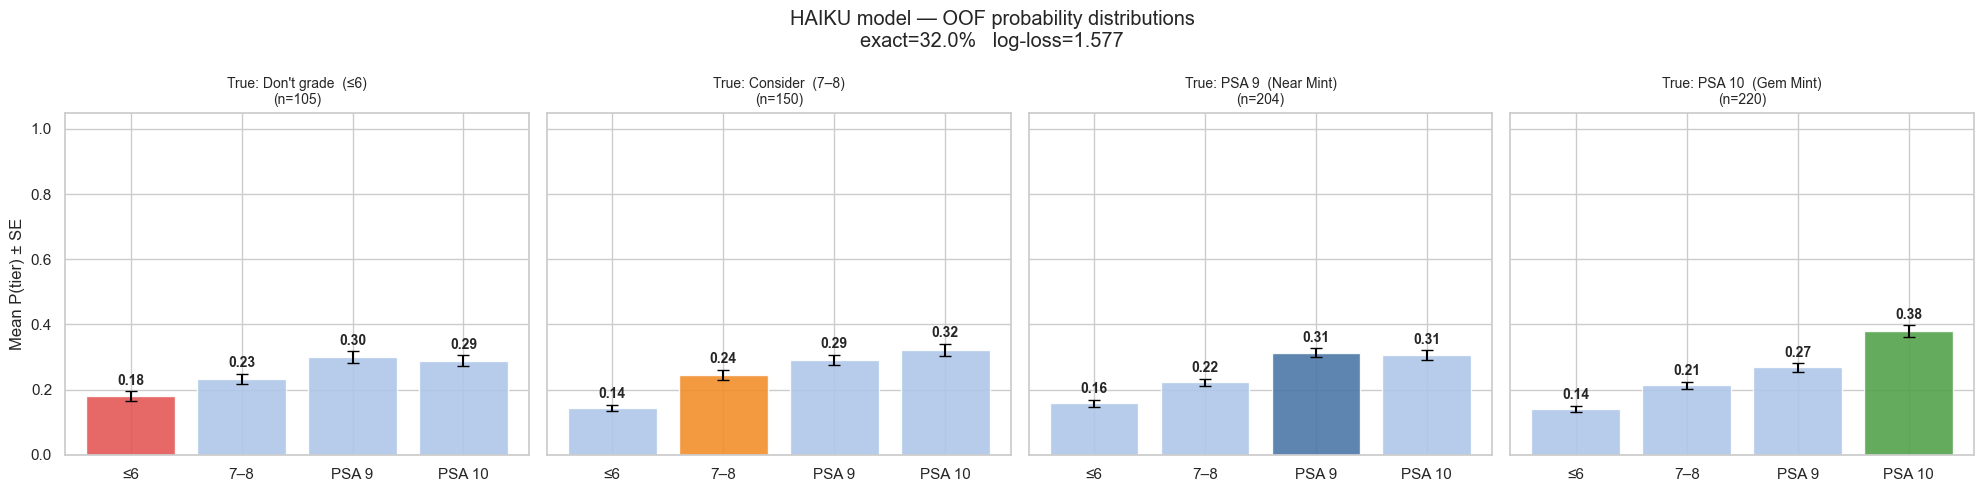

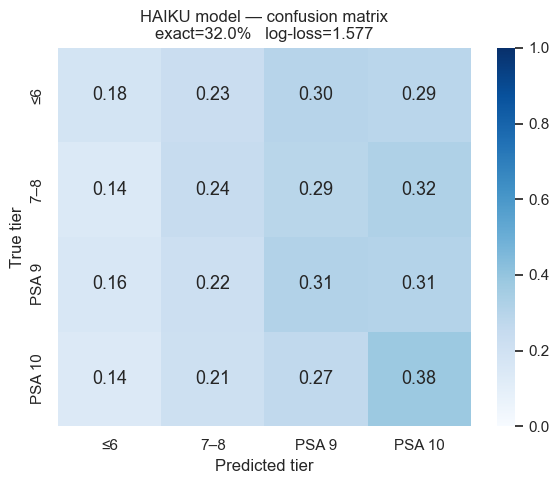

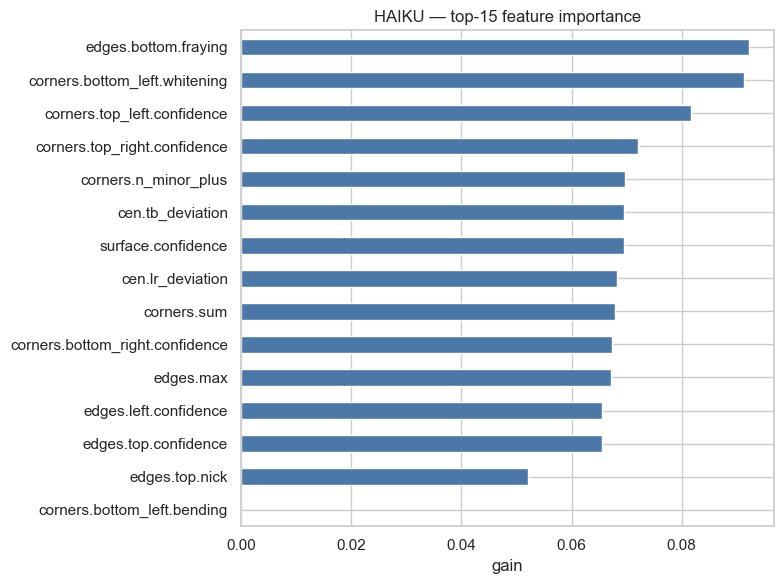

In [4]:
haiku_trainer.print_metrics()
haiku_trainer.plot_proba(save_path=str(OUT / "haiku_proba.png"))
haiku_trainer.plot_confusion(save_path=str(OUT / "haiku_confusion.png"))
haiku_trainer.plot_feature_importance(save_path=str(OUT / "haiku_importance.png"))

In [5]:
haiku_trainer.save(str(MODELS / "haiku_xgb.pkl"))

Saved HAIKU model bundle → models/haiku_xgb.pkl


## Train — CV model

In [6]:
df_cv   = pd.read_csv(BASE / "cv_features.csv")
cv_trainer = GradeXGBoostTrainer(source="cv", n_top_features=15)
cv_trainer.fit(df_cv)

[CV] 678 cards  (5-fold CV)
  Don't grade  (≤6)              105  (15%)
  Consider  (7–8)                150  (22%)
  PSA 9  (Near Mint)             204  (30%)
  PSA 10  (Gem Mint)             219  (32%)

  Selected 17 features (top-15 MI + centering)

  CV results:  log-loss=1.564  exact=35.5%  within-1=74.6%



══════════════════════════════════════════════════
  CV model — 5-fold CV metrics
──────────────────────────────────────────────────
  Cards:           678
  Features:        17
  Log-loss:        1.564
  Exact tier %:    35.5%
  Within-1 tier %: 74.6%
  Per-tier accuracy:
    ≤6      19.0%
    7–8     20.0%
    PSA 9   37.3%
    PSA 10  52.5%


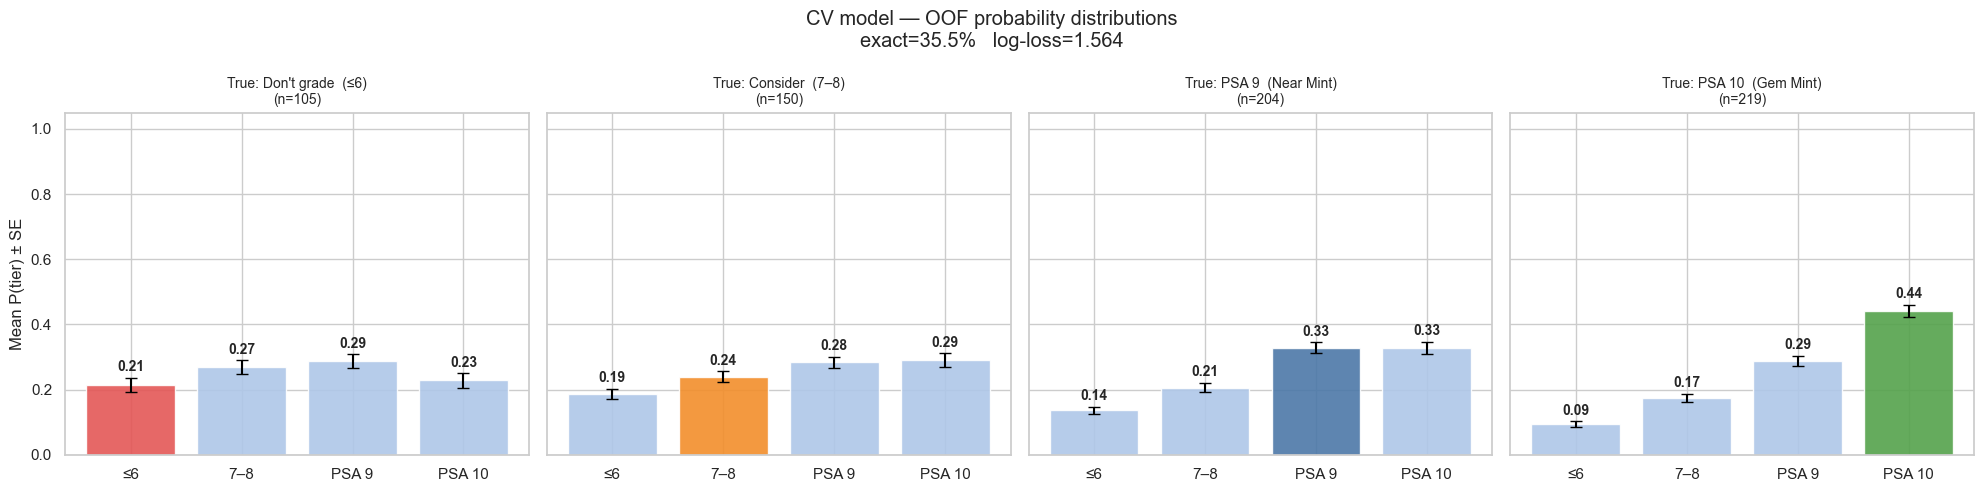

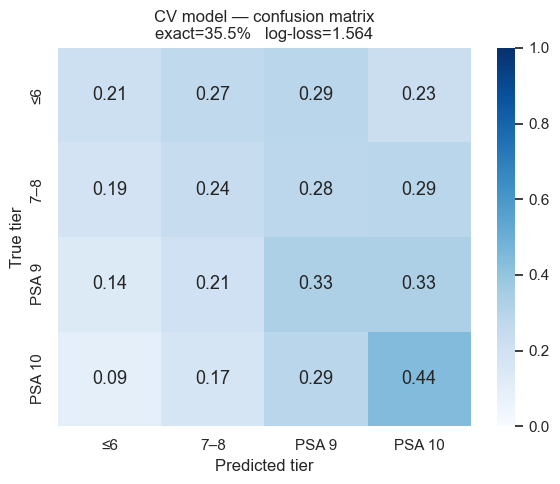

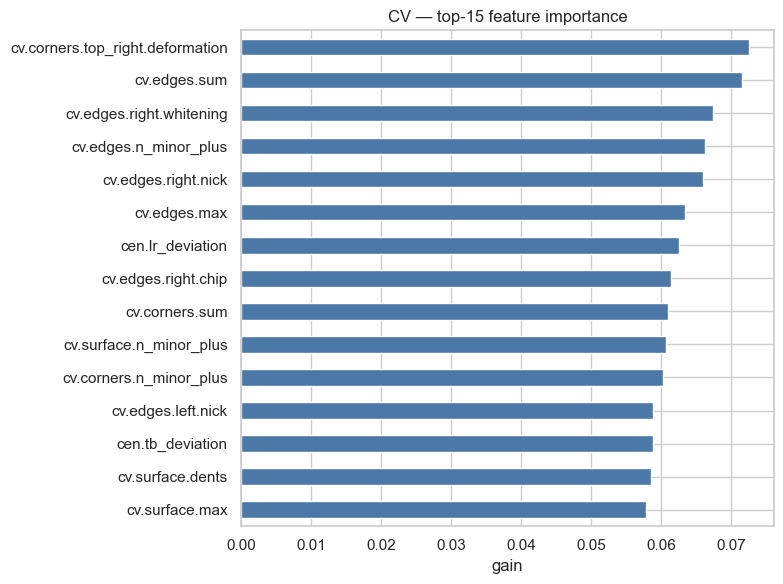

In [7]:
cv_trainer.print_metrics()
cv_trainer.plot_proba(save_path=str(OUT / "cv_proba.png"))
cv_trainer.plot_confusion(save_path=str(OUT / "cv_confusion.png"))
cv_trainer.plot_feature_importance(save_path=str(OUT / "cv_importance.png"))

In [8]:
cv_trainer.save(str(MODELS / "cv_xgb.pkl"))

Saved CV model bundle → models/cv_xgb.pkl


## Compare both models

In [9]:
# Side-by-side metrics table
rows = [haiku_trainer.cv_metrics_, cv_trainer.cv_metrics_]
comp = pd.DataFrame(rows).set_index("source")
print(comp[["n_cards","n_features","log_loss","exact%","within1%",
            "acc_≤6%","acc_7–8%","acc_9–10%"]].T.to_string())

KeyError: "['acc_9–10%'] not in index"